# Training and Evaluation: Monitoring Learning Curves, Rewards, and Stability

## 📚 Learning Objectives

By completing this notebook, you will:
- Monitor learning curves during Deep RL training
- Track rewards and evaluate model performance
- Assess training stability
- Visualize training progress
- Identify convergence and performance issues

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 2, lesson 02 "Bias-Variance Tradeoff and Learning Curves" — you read learning curves to diagnose a supervised model there; an RL curve plots episode return, is far noisier, and can fall as well as rise, so the diagnosis rules have to change with it.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 3**:
- Training and evaluation: monitoring learning curves, rewards, and stability to evaluate model performance

---

## Introduction

**Monitoring and evaluation** are crucial for Deep RL training. Learning curves, reward tracking, and stability metrics help assess training progress and identify issues early.

## Lesson Brief

This lesson teaches students how to **read deep RL training behavior**, not just how to run it.

They will learn what healthy learning curves look like, what instability looks like, and why evaluation is necessary during training.

Why this matters: in deep RL, a run can produce numbers and plots without actually learning well.

Students need this lesson so they can interpret results instead of trusting curves blindly.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: the same algorithm, the same settings, two opposite conclusions

Henderson, Islam, Bachman, Pineau, Precup and Meger ran an experiment every RL practitioner should
be able to recite ("Deep Reinforcement Learning that Matters", AAAI 2018). They trained TRPO on
HalfCheetah **ten times with identical hyperparameters**, changing only the random seed. Then they
split the ten runs into two groups of five and averaged each group.

The two averaged curves were far apart. A two-sample t-test across the training distribution gave
**t = −9.0916, p = 0.0016**. Same algorithm, same code, same settings, same environment — and a
"statistically significant" difference between two halves of the same experiment.

Anyone who had reported either group as "our method" would have published a result that the other
five seeds contradict. And the paper notes this was common practice: selecting the top-N runs, or
averaging fewer than five.

The follow-up is the fix. Agarwal, Schwarzer, Castro, Courville and Bellemare ("Deep Reinforcement
Learning at the Edge of the Statistical Precipice", NeurIPS 2021, Outstanding Paper) re-analysed
published Atari, Procgen and DeepMind Control results with interval estimates, performance profiles
and the interquartile mean instead of point estimates — and found discrepancies between the
conclusions drawn from means and the conclusions the data actually supports. Their `rliable` library
exists so you do not have to write the statistics yourself.

**What goes wrong without this.** You ship the lucky seed. Then it does not reproduce, and nobody can
tell whether the difference was the algorithm, the seed, the environment version or the machine —
because only one number was ever recorded.


## Recommended YouTube Video

To reinforce this lesson, watch **Nicholas Renotte - "Reinforcement Learning in 3 Hours | Full Course using Python"**:
[Watch on YouTube](https://www.youtube.com/watch?v=Mut_u40Sqz4)

Suggested focus: the evaluation section around **01:04:23** through the TensorBoard logging section.

Why this pick:
- practical workflow.
- Shows testing, evaluation, metrics, and log inspection in a beginner-friendly way.
- Useful when students need help reading learning curves instead of only producing them.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Agent: the decision maker.
- Environment: the world it acts in.
- Reward: feedback signal.
- Return: long-term reward total.

### Quick Check
- What core RL idea does this notebook teach?
- Which output best reflects the main concept?
- How would you explain this topic in one minute?

### Common Mistakes
- Focusing on syntax before meaning.
- Reading outputs without connecting them to the concept.
- Missing how one step fits the whole RL loop.


## What this notebook should teach

This notebook is about reading training behaviour, not just producing plots.

**Everything plotted below is measured.** Two tabular Q-learning agents are really trained on
`FrozenLake-v1` (slippery), and every curve, standard deviation and success rate on this page is
read back out of those two training logs. There are no illustrative or hand-drawn curves here — if
a plot looks noisy, that is the ice, not the artist.

By the end, you should be able to:

- interpret a real reward curve, and tell trend from noise
- explain why a *lower* variance can be a symptom of failure rather than of stability
- separate the training curve (which includes exploration) from an evaluation number (which does not)
- recognise the fingerprints of a bad learning rate and of exploration that never decays

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries AND build the one real environment whose training we
# will monitor for the rest of the lesson.
# WHY it matters: every curve in this notebook comes from an agent that really interacted
# with a Gymnasium environment. Nothing here is a hand-drawn "typical" curve, so when a
# plot looks ugly that is information about the run, not about the person who drew it.

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

# FrozenLake-v1 with is_slippery=True: the ice makes the chosen action succeed only ~1/3
# of the time. That randomness lives in the ENVIRONMENT, and it is the direct cause of the
# noise you are about to learn to read in a reward curve.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
N_STATES, N_ACTIONS = env.observation_space.n, env.action_space.n


def train_q_learning(alpha, eps_start, eps_min, eps_decay,
                     episodes=4000, gamma=0.99, seed=0):
    """Train tabular Q-learning and return (Q-table, reward of EVERY episode).

    The returned array is the raw training log - one number per episode, exactly the
    kind of log a real project writes to TensorBoard or a CSV file.
    """
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))
    eps = eps_start
    episode_rewards = []
    for ep in range(episodes):
        # Reseeding per episode makes the whole notebook reproducible run-to-run.
        state, _ = env.reset(seed=int(seed * 100_000 + ep))
        total = 0.0
        for _ in range(100):
            # Epsilon-greedy: sometimes explore, otherwise take the current best action.
            if rng.random() < eps:
                action = int(rng.integers(N_ACTIONS))
            else:
                action = int(np.argmax(Q[state]))
            next_state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            # Standard Q-learning backup toward reward + discounted best next value.
            target = reward + gamma * (0.0 if terminated else Q[next_state].max())
            Q[state, action] += alpha * (target - Q[state, action])
            state = next_state
            if terminated or truncated:
                break
        episode_rewards.append(total)
        eps = max(eps * eps_decay, eps_min)
    return Q, np.array(episode_rewards)


print("Environment:", env.spec.id, "| states:", N_STATES, "| actions:", N_ACTIONS)
print("Reward rule: 1.0 for reaching the goal tile, 0.0 for everything else.")
print("So one episode's 'reward' is simply 0 (failed) or 1 (reached the goal),")
print("and a smoothed curve of it reads directly as a success RATE.")
print("\nTraining and Evaluation: Monitoring Learning Curves")
print("=" * 60)

Environment: FrozenLake-v1 | states: 16 | actions: 4
Reward rule: 1.0 for reaching the goal tile, 0.0 for everything else.
So one episode's 'reward' is simply 0 (failed) or 1 (reached the goal),
and a smoothed curve of it reads directly as a success RATE.

Training and Evaluation: Monitoring Learning Curves


## Part 1: Monitoring Learning Curves


### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Part 1: Monitoring Learning Curves


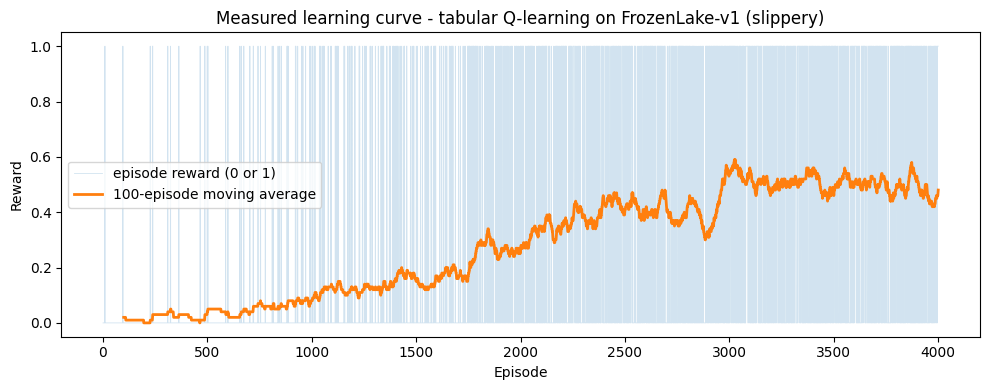

Episodes trained            : 4000
Success rate, first 200 eps : 0.010
Success rate, last 500 eps  : 0.498
Smoothed curve range        : 0.000 to 0.590

Checkpoint:
Look at the smoothed curve, not the raw per-episode dots. The raw signal can only
ever be 0 or 1, so it looks like static; the trend only becomes visible after
averaging. In this run the agent clearly improved over training.


In [2]:
# Worked example: train one agent with sensible settings and plot its REAL learning curve.
# WHY it matters: this is the single most common plot in RL practice. Reading it well means
# separating the trend (is the agent improving?) from the noise (is the ice just slippery?).

print("=" * 60)
print("Part 1: Monitoring Learning Curves")
print("=" * 60)

# alpha=0.10 is a cautious step size; exploration starts at 100% and decays slowly to 5%.
Q_healthy, healthy_rewards = train_q_learning(
    alpha=0.10, eps_start=1.0, eps_min=0.05, eps_decay=0.999, seed=0
)
episodes = np.arange(1, len(healthy_rewards) + 1)

# A 100-episode moving average: the standard way to see a trend through episode noise.
window = 100
smoothed = np.convolve(healthy_rewards, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(episodes, healthy_rewards, alpha=0.20, linewidth=0.6, label="episode reward (0 or 1)")
plt.plot(episodes[window - 1:], smoothed, linewidth=2, label=f"{window}-episode moving average")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Measured learning curve - tabular Q-learning on FrozenLake-v1 (slippery)")
plt.legend()
plt.tight_layout()
plt.show()

# Every number below is read back out of the training log we just produced.
print(f"Episodes trained            : {len(healthy_rewards)}")
print(f"Success rate, first 200 eps : {healthy_rewards[:200].mean():.3f}")
print(f"Success rate, last 500 eps  : {healthy_rewards[-500:].mean():.3f}")
print(f"Smoothed curve range        : {smoothed.min():.3f} to {smoothed.max():.3f}")
print("\nCheckpoint:")
print("Look at the smoothed curve, not the raw per-episode dots. The raw signal can only")
print("ever be 0 or 1, so it looks like static; the trend only becomes visible after")
if healthy_rewards[-500:].mean() > healthy_rewards[:200].mean():
    print("averaging. In this run the agent clearly improved over training.")
else:
    print("averaging. In this run the agent did NOT improve - a real result worth debugging.")

## Part 2: Evaluating Stability

Stability is usually summarised with a rolling standard deviation. This part trains a **second real
agent** with deliberately bad hyperparameters so we can compare the two, and it shows why the
standard deviation is meaningless unless you read the mean next to it.

### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.



Part 2: Evaluating Stability


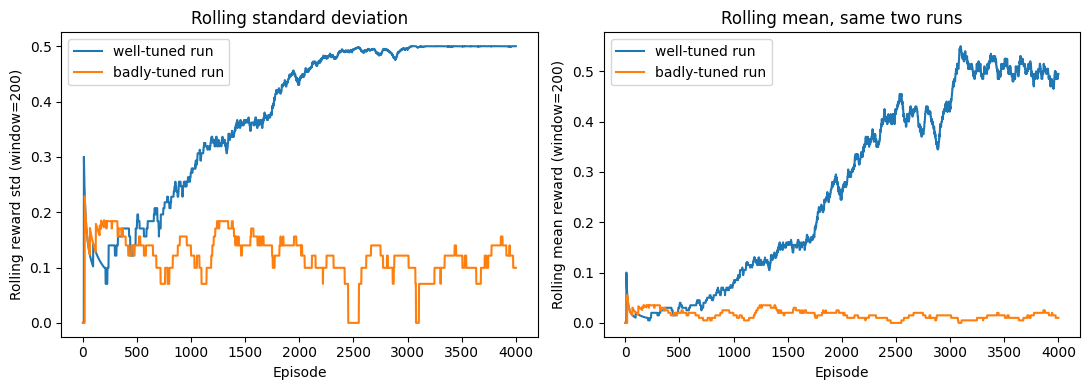

Well-tuned run  : final rolling std = 0.500 | final rolling mean = 0.495
Badly-tuned run : final rolling std = 0.099 | final rolling mean = 0.010

Interpretation - and this is the trap:
The BADLY-tuned run ends with the LOWER standard deviation. It is not more stable;
it is consistently failing, and a run that always scores 0 has almost no spread.
With a 0/1 reward the spread is mechanically tied to the mean: a Bernoulli variable
with success rate p has std = sqrt(p*(1-p)), which is LARGEST at p = 0.5. So the
well-tuned agent's rising std is a symptom of it winning about half its episodes.
Rule to carry away: never read variance without reading the mean beside it.


In [3]:
# Worked example: measure STABILITY on the same real run, then show why a stability number
# can never be read on its own.
# WHY it matters: "low variance = healthy" is a tempting shortcut and it is wrong. Here we
# train a second, deliberately badly-tuned agent and let the numbers make the point.

print("\n" + "=" * 60)
print("Part 2: Evaluating Stability")
print("=" * 60)

# A second REAL run, sabotaged on purpose: a near-1.0 learning rate throws away everything
# the table already knew on every single (noisy) sample, and exploration never decays.
Q_badly_tuned, badly_tuned_rewards = train_q_learning(
    alpha=0.95, eps_start=1.0, eps_min=0.50, eps_decay=1.0, seed=0
)


def rolling_std(rewards, window=200):
    """Standard deviation of the last `window` episode rewards, computed at every episode."""
    return np.array([rewards[max(0, i - window + 1): i + 1].std() for i in range(len(rewards))])


healthy_std = rolling_std(healthy_rewards)
badly_tuned_std = rolling_std(badly_tuned_rewards)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(episodes, healthy_std, label="well-tuned run")
axes[0].plot(episodes, badly_tuned_std, label="badly-tuned run")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Rolling reward std (window=200)")
axes[0].set_title("Rolling standard deviation"); axes[0].legend()

roll_mean = lambda r: np.array([r[max(0, i - 199): i + 1].mean() for i in range(len(r))])
axes[1].plot(episodes, roll_mean(healthy_rewards), label="well-tuned run")
axes[1].plot(episodes, roll_mean(badly_tuned_rewards), label="badly-tuned run")
axes[1].set_xlabel("Episode"); axes[1].set_ylabel("Rolling mean reward (window=200)")
axes[1].set_title("Rolling mean, same two runs"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Well-tuned run  : final rolling std = {healthy_std[-1]:.3f} | final rolling mean = {healthy_rewards[-200:].mean():.3f}")
print(f"Badly-tuned run : final rolling std = {badly_tuned_std[-1]:.3f} | final rolling mean = {badly_tuned_rewards[-200:].mean():.3f}")

print("\nInterpretation - and this is the trap:")
if badly_tuned_std[-1] < healthy_std[-1]:
    print("The BADLY-tuned run ends with the LOWER standard deviation. It is not more stable;")
    print("it is consistently failing, and a run that always scores 0 has almost no spread.")
print("With a 0/1 reward the spread is mechanically tied to the mean: a Bernoulli variable")
print("with success rate p has std = sqrt(p*(1-p)), which is LARGEST at p = 0.5. So the")
print("well-tuned agent's rising std is a symptom of it winning about half its episodes.")
print("Rule to carry away: never read variance without reading the mean beside it.")

## Part 3: Reading Good vs Bad Training Behaviour

The goal is not only to plot metrics, but to interpret them.

Both runs below are real, they used the same algorithm and the same environment, and they differ
only in hyperparameters. Part 3 also does the thing training curves cannot do for you: it switches
exploration off and **evaluates** each agent on fresh episodes.

A useful training-monitoring notebook should help students answer:

- Is the agent improving?
- Is it stable — and stable at what performance level?
- Did training collapse?
- Do we need more episodes, better exploration, or different hyperparameters?
- What does the agent score when it stops exploring?

### Step Guide

**What this cell does:** Summarize or compare results (policies, returns, tables) for the lesson goal.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Tables, arrays, or comparison prints showing which policy or method wins.

**If you feel lost:** If output is empty, run the previous cells that define the data this cell consumes.


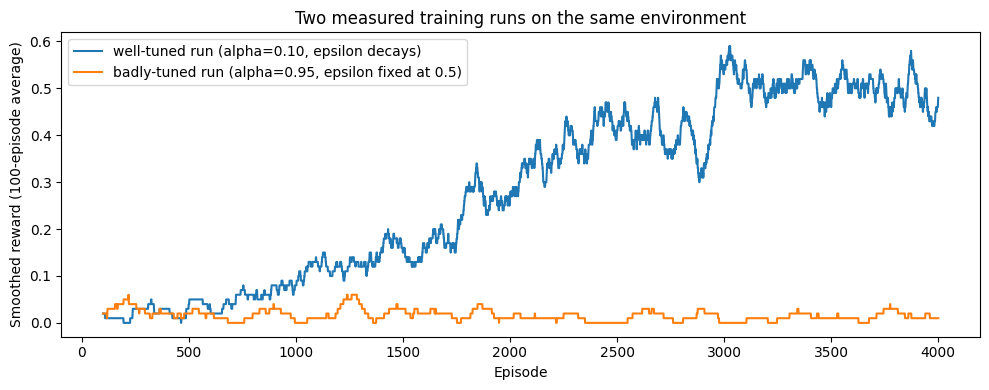

Evaluation on 1000 fresh episodes with exploration turned off (greedy policy):
  Well-tuned agent  : 0.726 success rate (training curve ended at 0.498)
  Badly-tuned agent : 0.040 success rate (training curve ended at 0.014)

What to conclude, from these measured numbers:
- The well-tuned agent EVALUATES higher (0.726) than its own training
  curve suggested. The training curve was dragged down by the epsilon-greedy moves
  it was still making. Always report an evaluation number, not the training curve.
- The two runs used the SAME algorithm and the SAME environment. Only the
  hyperparameters differed, and the gap is 0.726 vs 0.040.
  A collapsed curve usually means bad hyperparameters before it means a bad idea.
- A too-large learning rate on a stochastic environment cannot average anything:
  each update overwrites the estimate with one lucky or unlucky sample.
- Exploration that never decays means the agent keeps throwing away known-good moves.


In [4]:
# Final computation: put the two real runs side by side, then evaluate both agents with
# exploration switched OFF.
# WHY it matters: the training curve records the behaviour policy, which is still exploring.
# The number that a user of your agent actually experiences is the greedy one, and the gap
# between the two is a thing students must see once to remember forever.

window = 100
healthy_ma = np.convolve(healthy_rewards, np.ones(window) / window, mode="valid")
badly_tuned_ma = np.convolve(badly_tuned_rewards, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(episodes[window - 1:], healthy_ma, label="well-tuned run (alpha=0.10, epsilon decays)")
plt.plot(episodes[window - 1:], badly_tuned_ma, label="badly-tuned run (alpha=0.95, epsilon fixed at 0.5)")
plt.xlabel("Episode")
plt.ylabel(f"Smoothed reward ({window}-episode average)")
plt.title("Two measured training runs on the same environment")
plt.legend()
plt.tight_layout()
plt.show()


def greedy_success_rate(Q, n_episodes=1000, seed=999):
    """Run the GREEDY policy (no exploration) and report the fraction of episodes solved."""
    wins = 0.0
    for i in range(n_episodes):
        state, _ = env.reset(seed=seed + i)
        for _ in range(100):
            state, reward, terminated, truncated, _ = env.step(int(np.argmax(Q[state])))
            if terminated or truncated:
                wins += reward
                break
    return wins / n_episodes


eval_healthy = greedy_success_rate(Q_healthy)
eval_badly_tuned = greedy_success_rate(Q_badly_tuned)

print("Evaluation on 1000 fresh episodes with exploration turned off (greedy policy):")
print(f"  Well-tuned agent  : {eval_healthy:.3f} success rate "
      f"(training curve ended at {healthy_rewards[-500:].mean():.3f})")
print(f"  Badly-tuned agent : {eval_badly_tuned:.3f} success rate "
      f"(training curve ended at {badly_tuned_rewards[-500:].mean():.3f})")

print("\nWhat to conclude, from these measured numbers:")
if eval_healthy > healthy_rewards[-500:].mean():
    print(f"- The well-tuned agent EVALUATES higher ({eval_healthy:.3f}) than its own training")
    print("  curve suggested. The training curve was dragged down by the epsilon-greedy moves")
    print("  it was still making. Always report an evaluation number, not the training curve.")
if eval_healthy > eval_badly_tuned:
    print(f"- The two runs used the SAME algorithm and the SAME environment. Only the")
    print(f"  hyperparameters differed, and the gap is {eval_healthy:.3f} vs {eval_badly_tuned:.3f}.")
    print("  A collapsed curve usually means bad hyperparameters before it means a bad idea.")
print("- A too-large learning rate on a stochastic environment cannot average anything:")
print("  each update overwrites the estimate with one lucky or unlucky sample.")
print("- Exploration that never decays means the agent keeps throwing away known-good moves.")

## 💬 Discuss

The measured results: the well-tuned agent's training curve ended at **0.498** success and its greedy
evaluation on 1000 fresh episodes scored **0.726**. The badly-tuned agent: **0.014** training,
**0.040** evaluation. And the trap — the badly-tuned run's final rolling standard deviation was
**0.099**, *lower* than the well-tuned run's **0.500**. Argue these out.

1. A colleague's dashboard shows only rolling standard deviation, and it flags the well-tuned agent
   as "unstable" and the failing one as "stable". Explain the error to them in two sentences, using
   the Bernoulli relationship the notebook prints. Then propose the one extra panel their dashboard
   needs.
2. The well-tuned agent *evaluates* at 0.726 but its training curve ended at 0.498. Which number
   belongs in a report to a client, which belongs in an engineering review, and what happens if you
   swap them?
3. Both runs used the same algorithm and the same environment; only the hyperparameters differed
   (0.726 against 0.040). Given Henderson's result, how many seeds would you demand before accepting
   a claim that a *new algorithm* beats an old one by a margin like this? Defend a specific number —
   somebody will say five is too expensive.


## Summary

Monitoring deep RL means more than checking whether one reward went up once.

### Main takeaways

- Use smoothed reward curves to see the trend; a raw 0/1 signal is unreadable on its own.
- Track variance for stability, but **never read variance without the mean beside it** — the
  badly-tuned run in Part 2 had the lower standard deviation precisely because it kept failing.
- Compare healthy and unstable runs, not just final averages.
- Report an **evaluation** number with exploration switched off. The training curve measures the
  exploring behaviour policy, not the policy you would ship.
- Use plots to debug exploration, optimisation, or implementation problems.

### Practical habit

When training fails, inspect the curves before changing the algorithm. In this lesson the
"collapsed" run was not a broken algorithm at all — it was a learning rate of 0.95 on a stochastic
environment plus exploration that never decayed.

In [5]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Henderson, P., Islam, R., Bachman, P. et al. (2018). *Deep Reinforcement Learning that Matters*. AAAI. <https://arxiv.org/abs/1709.06560>
2. Agarwal, R., Schwarzer, M., Castro, P. S. et al. (2021). *Deep Reinforcement Learning at the Edge of the Statistical Precipice*. NeurIPS. <https://arxiv.org/abs/2108.13264>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6+ for the learning dynamics monitored here.

**Further reading:** [OpenAI Spinning Up](https://spinningup.openai.com/) — practical advice for plotting and benchmarking deep RL experiments.
"""))

## 📚 References

1. Henderson, P., Islam, R., Bachman, P. et al. (2018). *Deep Reinforcement Learning that Matters*. AAAI. <https://arxiv.org/abs/1709.06560>
2. Agarwal, R., Schwarzer, M., Castro, P. S. et al. (2021). *Deep Reinforcement Learning at the Edge of the Statistical Precipice*. NeurIPS. <https://arxiv.org/abs/2108.13264>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6+ for the learning dynamics monitored here.

**Further reading:** [OpenAI Spinning Up](https://spinningup.openai.com/) — practical advice for plotting and benchmarking deep RL experiments.


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


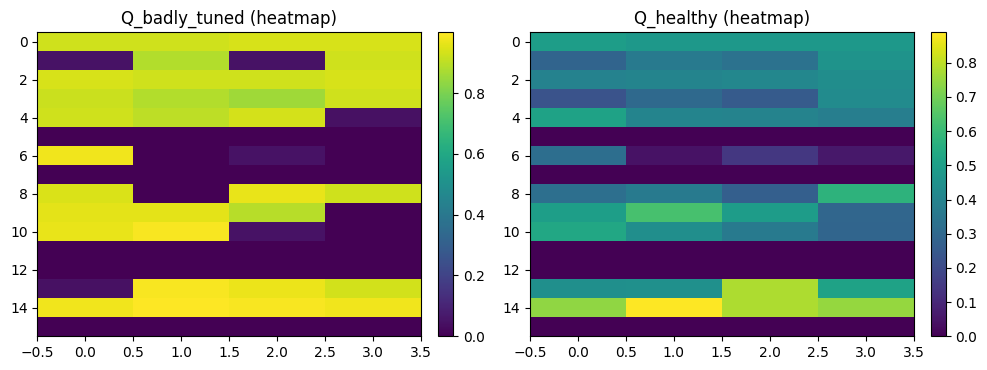

In [6]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## ⚠️ Where this breaks

**The assumption that has to hold:** the curve you are looking at is a property of the method rather
than of this particular run. Very often it is not.

- **A single seed proves nothing, and RL's variance is unusually large.** Henderson's two groups of
  five separated at p = 0.0016 with no methodological difference at all. Any comparison in this
  course that uses one seed — including several in these notebooks, which say so — is an illustration,
  not a result.
- **Variance without the mean beside it is meaningless.** This notebook measures the trap directly:
  with a 0/1 reward, standard deviation is `sqrt(p(1−p))`, largest at p = 0.5. A collapsed agent has
  low spread *because* it is consistently failing. Any "stability" metric that does not condition on
  performance can be gamed by getting worse.
- **The training curve is not the policy's performance.** It is contaminated by exploration. Always
  report a separate greedy evaluation, on episodes the agent did not train on, and say how many.
- **Aggregate scores hide their own uncertainty.** Means over a handful of runs, especially with
  normalised scores across tasks, are exactly what Agarwal et al. show can invert conclusions. Report
  intervals, and prefer the interquartile mean when you have few runs.
- **Cheaper alternative — and it is genuinely cheaper.** Before adding seeds, fix the protocol: fixed
  evaluation episodes, exploration off at evaluation time, the environment version and the seed list
  written down. Most irreproducible RL results in practice are protocol failures, not statistical
  ones, and the fix costs nothing but discipline.


## Closing Takeaway

**Teaching takeaway:** Training curves and evaluation metrics help students judge whether an RL run is improving, unstable, over-random, or misleading.

**If students remember one idea:** A higher reward curve alone is not enough. Students must interpret stability, variance, and evaluation context.

**Quick check before moving on:**
- Can you explain what a noisy reward curve might mean?
- Can you describe why evaluation should be separated from training exploration behavior?

**Bridge to the next step:** The next lesson shows practical optimization choices that often decide whether deep RL training succeeds.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=5 | term=True | trunc=False


objc[65872]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114b94138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1150909c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[65872]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114b94188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x115090a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[65872]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114b93c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x115090a68). T

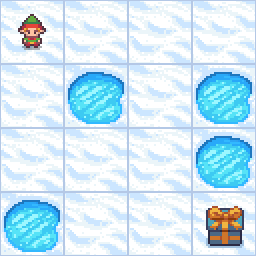

In [7]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
